# J09 — Transfert de chaleur dans le sol

**Physique et hydrodynamique des sols** — S. J. Gumiere

*Atelier du Jour 9 : propriétés thermiques, onde amortie, schéma implicite, module Heat Transport de HYDRUS-1D*

> Version **instructeur** : code complet et résultats.

## Mise en place

Unités : SI pour les propriétés (W m$^{-1}$ K$^{-1}$, J m$^{-3}$ K$^{-1}$), puis cm et jours pour les simulations (HYDRUS : g, cm, j).
Les projets HYDRUS-1D sont dans `../../hydrus/` (lecteurs dans `../hydrus_io.py`).

In [1]:
import sys
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.linalg import solve_banded
from hydrus_io import read_obs_node

HYD = "../../hydrus"
omega = 2 * np.pi        # pulsation de l'onde journalière (rad/j)
sec_par_jour = 86400.0   # secondes dans un jour

## Exercice 1 — Propriétés thermiques en fonction de la teneur en eau  *(≈ 12 min)*

Conductivité thermique de Chung & Horton (1987) : $\lambda(\theta) = b_1 + b_2\theta + b_3\theta^{0,5}$ (W m$^{-1}$ K$^{-1}$), avec
sable (0,228 ; −2,406 ; 4,909), loam (0,243 ; 0,393 ; 1,534), argile (−0,197 ; −0,962 ; 2,521) — valeurs par défaut de HYDRUS-1D.
Capacité thermique volumique de de Vries : $C = \theta_n C_n + \theta_o C_o + \theta C_w$ avec $C_n = 1{,}92$, $C_o = 2{,}51$,
$C_w = 4{,}18$ MJ m$^{-3}$ K$^{-1}$ ; $\theta_n = 1 - \theta_s - \theta_o$ ($\theta_s$ = 0,43 / 0,43 / 0,38 ; $\theta_o = 0$).

1. Calculer et tracer $\lambda(\theta)$, $C(\theta)$ et $D_T = \lambda/C$ (en cm²/j) pour les trois sols.
2. À $\theta = 0{,}6\,\theta_s$, calculer $D_T$, la profondeur d'amortissement journalière $d = \sqrt{2D_T/\omega}$ et annuelle.
3. Convertir $b_1, b_2, b_3$ (W m$^{-1}$ K$^{-1}$ → g cm j$^{-3}$ K$^{-1}$) et $C_n, C_o, C_w$ (J m$^{-3}$ K$^{-1}$ → g cm$^{-1}$ j$^{-2}$ K$^{-1}$)
   pour le loam. Démontrer les facteurs (1 W = 1 kg m² s$^{-3}$) puis comparer aux valeurs du bloc E de `J09_chaleur_sans_convection/SELECTOR.IN`
   (les lire dans le fichier).
4. Pour le loam à $h = -100$ cm ($\theta = 0{,}243$, projet HYDRUS), donner $\lambda$, $C$, $D_T$ et $d$ : ce sont les valeurs de référence de l'exercice 4.

**Paramètres des trois sols et formules de λ(θ) et C(θ)**

In [2]:
# capacités thermiques volumiques des constituants (J m-3 K-1), de Vries (1963)
Cn = 1.92e6   # minéraux
Co = 2.51e6   # matière organique
Cw = 4.18e6   # eau

# conductivité thermique (W m-1 K-1) : Chung & Horton (1987), lambda = b1 + b2 theta + b3 theta^0.5
def lam_CH(theta, b1, b2, b3):
    return b1 + b2 * theta + b3 * np.sqrt(theta)

# capacité thermique volumique (J m-3 K-1) : de Vries, somme des fractions volumiques des constituants
def C_vol(theta, theta_s, theta_o):
    theta_n = 1 - theta_s - theta_o
    return Cn * theta_n + Co * theta_o + Cw * theta

# paramètres b1, b2, b3 (valeurs par défaut de HYDRUS-1D) et porosité des trois sols
sols = ["sable", "loam", "argile"]
b1_sol = [0.228, 0.243, -0.197]
b2_sol = [-2.406, 0.393, -0.962]
b3_sol = [4.909, 1.534, 2.521]
theta_s_sol = [0.43, 0.43, 0.38]

print("loam, theta = 0,25 : lambda =", round(lam_CH(0.25, 0.243, 0.393, 1.534), 3), "W/m/K ; C =", C_vol(0.25, 0.43, 0.0) / 1e6, "MJ/m³/K")

loam, theta = 0,25 : lambda = 1.108 W/m/K ; C = 2.1394 MJ/m³/K


**1a. Conductivité thermique λ(θ)**

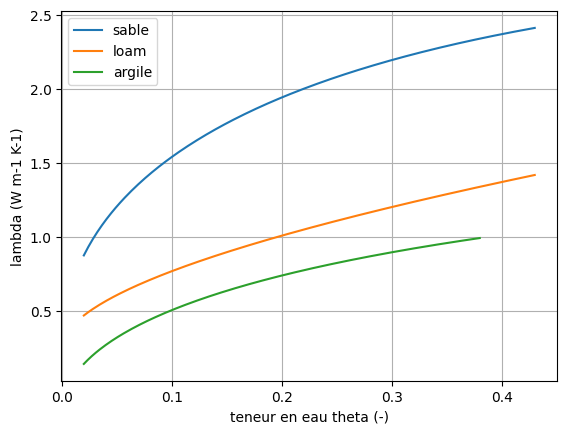

In [3]:
plt.figure()
for i in range(3):
    theta = np.linspace(0.02, theta_s_sol[i], 200)
    lam = lam_CH(theta, b1_sol[i], b2_sol[i], b3_sol[i])
    plt.plot(theta, lam, label=sols[i])
plt.xlabel("teneur en eau theta (-)")
plt.ylabel("lambda (W m-1 K-1)")
plt.legend()
plt.grid(True)
plt.show()

**1b. Capacité thermique volumique C(θ)**

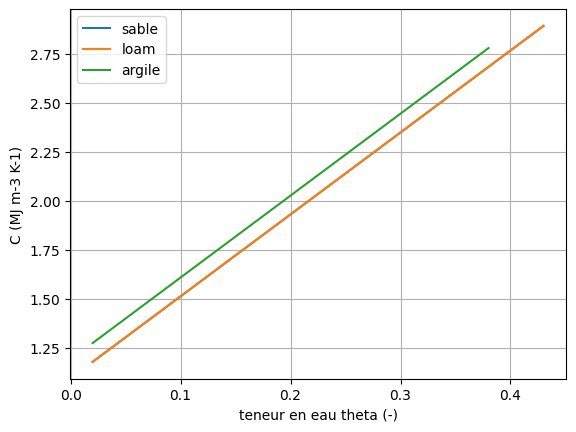

In [4]:
plt.figure()
for i in range(3):
    theta = np.linspace(0.02, theta_s_sol[i], 200)
    C = C_vol(theta, theta_s_sol[i], 0.0)
    plt.plot(theta, C / 1e6, label=sols[i])
plt.xlabel("teneur en eau theta (-)")
plt.ylabel("C (MJ m-3 K-1)")
plt.legend()
plt.grid(True)
plt.show()

**1c. Diffusivité thermique D_T(θ) = λ/C**

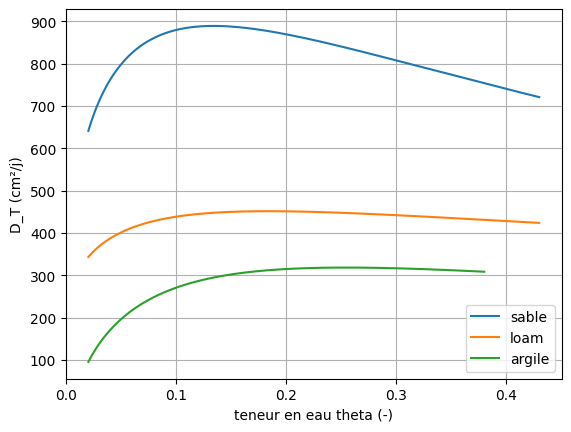

In [5]:
plt.figure()
for i in range(3):
    theta = np.linspace(0.02, theta_s_sol[i], 200)
    lam = lam_CH(theta, b1_sol[i], b2_sol[i], b3_sol[i])
    C = C_vol(theta, theta_s_sol[i], 0.0)
    # lambda / C est en m²/s ; en cm²/j : x 1e4 (m² -> cm²) x 86400 (par seconde -> par jour)
    D_T = lam / C * 1e4 * sec_par_jour
    plt.plot(theta, D_T, label=sols[i])
plt.xlabel("teneur en eau theta (-)")
plt.ylabel("D_T (cm²/j)")
plt.legend()
plt.grid(True)
plt.show()

**2. Profondeurs d'amortissement à θ = 0,6 θs**

In [6]:
lignes = []
for i in range(3):
    theta = 0.6 * theta_s_sol[i]
    lam = lam_CH(theta, b1_sol[i], b2_sol[i], b3_sol[i])
    C = C_vol(theta, theta_s_sol[i], 0.0)
    D_T = lam / C * 1e4 * sec_par_jour                 # cm²/j
    d_jour = np.sqrt(2 * D_T / omega)                  # onde journalière (cm)
    d_an = np.sqrt(2 * D_T / (omega / 365)) / 100      # onde annuelle (m) : pulsation 365 fois plus petite
    lignes.append([sols[i], theta, lam, C / 1e6, D_T, d_jour, d_an])

tableau = pd.DataFrame(lignes, columns=["sol", "theta", "lam", "C_MJ", "D_T_cm2_j", "d_jour_cm", "d_an_m"])
print(tableau.round(3))

      sol  theta    lam   C_MJ  D_T_cm2_j  d_jour_cm  d_an_m
0   sable  0.258  2.101  2.173    835.320     16.306   3.115
1    loam  0.258  1.124  2.173    446.772     11.925   2.278
2  argile  0.228  0.787  2.143    317.403     10.051   1.920


**3a. Facteurs de conversion vers les unités de HYDRUS (g, cm, j)**

In [7]:
# 1 W m-1 K-1 = 1 kg m s-3 K-1  ->  g cm j-3 K-1 : x 1e3 (kg -> g), x 1e2 (m -> cm), x 86400³ (s-3 -> j-3)
f_lam = 1e3 * 1e2 * sec_par_jour**3
# 1 J m-3 K-1 = 1 kg m-1 s-2 K-1  ->  g cm-1 j-2 K-1 : x 1e3, x 1e-2 (m-1 -> cm-1), x 86400² (s-2 -> j-2)
f_C = 1e3 * 1e-2 * sec_par_jour**2
print(f"facteur lambda = {f_lam:.4e} ; facteur C = {f_C:.4e}")

# paramètres du loam dans les unités HYDRUS
b1_h = b1_sol[1] * f_lam
b2_h = b2_sol[1] * f_lam
b3_h = b3_sol[1] * f_lam
Cn_h = Cn * f_C
Co_h = Co * f_C
Cw_h = Cw * f_C
print(f"loam, unités HYDRUS : b1 = {b1_h:.5e}, b2 = {b2_h:.5e}, b3 = {b3_h:.5e}")
print(f"                      Cn = {Cn_h:.5e}, Co = {Co_h:.5e}, Cw = {Cw_h:.5e}")

facteur lambda = 6.4497e+19 ; facteur C = 7.4650e+10
loam, unités HYDRUS : b1 = 1.56728e+19, b2 = 2.53474e+19, b3 = 9.89388e+19
                      Cn = 1.43327e+17, Co = 1.87370e+17, Cw = 3.12035e+17


**3b. Lecture du bloc E de SELECTOR.IN et comparaison**

In [8]:
# le bloc E est la ligne qui suit l'en-tête commençant par "thn" (thn, tho, dispersivité, b1, b2, b3, Cn, Co, Cw)
fichier = open(HYD + "/J09_chaleur_sans_convection/SELECTOR.IN")
lignes_sel = fichier.read().splitlines()
fichier.close()
for i in range(len(lignes_sel)):
    if lignes_sel[i].strip().startswith("thn"):
        print(lignes_sel[i])
        print(lignes_sel[i + 1])
        valeurs_sel = np.array(lignes_sel[i + 1].split(), dtype=float)

nos_valeurs = np.array([b1_h, b2_h, b3_h, Cn_h, Co_h, Cw_h])
valeurs_hydrus = valeurs_sel[3:9]
ecart = np.abs(nos_valeurs / valeurs_hydrus - 1)
print(f"écart relatif max (b1..Cw) : {ecart.max():.2e}")

 thn  tho  lambda           b1           b2           b3           Cn           C0           Cw
0.57  0.0     5.0 1.567280e+19 2.534740e+19 9.893880e+19 1.433270e+17 1.873700e+17 3.120350e+17
écart relatif max (b1..Cw) : 2.65e-06


**4. Valeurs de référence : loam à θ = 0,243**

In [9]:
b1_loam = b1_sol[1]
b2_loam = b2_sol[1]
b3_loam = b3_sol[1]
theta_s_loam = theta_s_sol[1]
theta_ref = 0.243   # loam à h = -100 cm (projet HYDRUS)

lam_loam = lam_CH(theta_ref, b1_loam, b2_loam, b3_loam)     # W m-1 K-1
C_loam = C_vol(theta_ref, theta_s_loam, 0.0)                # J m-3 K-1
DT_loam = lam_loam / C_loam * 1e4 * sec_par_jour            # cm²/j
d_loam = np.sqrt(2 * DT_loam / omega)                       # cm
print(f"loam, theta = {theta_ref} : lambda = {lam_loam:.3f} W/m/K ; C = {C_loam / 1e6:.3f} MJ/m³/K")
print(f"D_T = {DT_loam:.1f} cm²/j ; d_jour = {d_loam:.2f} cm ; d_an = {d_loam * np.sqrt(365) / 100:.2f} m")

loam, theta = 0.243 : lambda = 1.095 W/m/K ; C = 2.110 MJ/m³/K
D_T = 448.2 cm²/j ; d_jour = 11.94 cm ; d_an = 2.28 m


**Commentaire (instructeur).** La conductivité du sable est la plus sensible à $\theta$ (ponts d'eau entre gros grains), celle de l'argile la plus faible ;
$D_T$ passe par un maximum vers $\theta \approx 0{,}1$–0,2 puis décroît car $C$ continue de croître. Les facteurs $6{,}45\times10^{19}$ et
$7{,}46\times10^{10}$ reproduisent exactement les valeurs du bloc E (`1.56728e19`, `3.12035e17`, etc.) : ce ne sont que des changements d'unités.
À $\theta = 0{,}243$, $D_T = 448$ cm²/j et $d = 11{,}9$ cm : valeur à retrouver dans les simulations HYDRUS.

## Exercice 2 — Ajustement d'une onde amortie sur des températures mesurées  *(≈ 15 min)*

`data/J09_temperatures_horaires.csv` : températures horaires « mesurées » à 5, 10, 20 et 40 cm pendant 5 jours (`t_j`, `T_5cm`, … ; bruit
de capteur et dérive lente de la moyenne).

1. Tracer les quatre séries. Pour chaque profondeur, ajuster par `curve_fit` le modèle $T = T_m + a\,t + A\sin(\omega t + \varphi)$
   ($\omega = 2\pi$ rad/j connu) ; récupérer $A(z) > 0$ et $\varphi(z)$ (ramener $A$ positif et $\varphi$ continu avec `np.unwrap`).
2. Régresser $\ln A$ sur $z$ (pente $-1/d_A$) et $\varphi$ sur $z$ (pente $-1/d_\varphi$) : deux estimations de $d$, donc de
   $D_T = \omega d^2/2$. Comparer entre elles et à la valeur du loam (exercice 1).
3. Quelle est l'heure du maximum à chaque profondeur ? Vérifier que le retard croît linéairement avec $z$.
4. Refaire l'ajustement en omettant la dérive ($a = 0$) : effet sur $A$, $\varphi$ et $d$ ? Pourquoi la profondeur 40 cm est-elle la plus incertaine ?

**Lecture des données et tracé des quatre séries**

       t_j  T_5cm  T_10cm  T_20cm  T_40cm
0  0.00000  13.28   16.21   18.68   18.14
1  0.04167  12.70   15.76   18.24   18.31
2  0.08333  12.09   14.60   17.78   18.06
3  0.12500  11.98   14.11   17.43   18.56
4  0.16667  12.60   14.29   17.12   18.57
nombre de mesures : 121


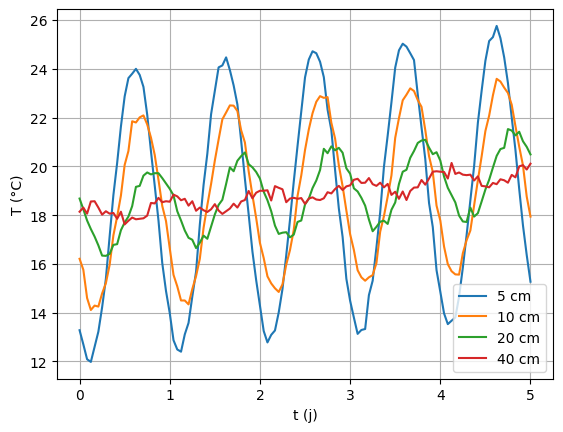

In [10]:
tp = pd.read_csv("data/J09_temperatures_horaires.csv")
t = tp["t_j"].to_numpy()
zs = np.array([5, 10, 20, 40])     # profondeurs des capteurs (cm)
print(tp.head())
print("nombre de mesures :", len(tp))

plt.figure()
plt.plot(t, tp["T_5cm"], label="5 cm")
plt.plot(t, tp["T_10cm"], label="10 cm")
plt.plot(t, tp["T_20cm"], label="20 cm")
plt.plot(t, tp["T_40cm"], label="40 cm")
plt.xlabel("t (j)")
plt.ylabel("T (°C)")
plt.legend()
plt.grid(True)
plt.show()

**1. Ajustement du modèle à chaque profondeur**

In [11]:
# modèle : moyenne + dérive lente + onde journalière (omega connu)
def modele(t, Tm, a, A, phi):
    return Tm + a * t + A * np.sin(omega * t + phi)

lignes = []
for z in zs:
    T = tp[f"T_{z}cm"].to_numpy()
    popt, pcov = curve_fit(modele, t, T, p0=[20, 0, 5, 0])
    Tm = popt[0]
    a = popt[1]
    A = popt[2]
    phi = popt[3]
    # amplitude positive : A sin(x) = -A sin(x + pi)
    if A < 0:
        A = -A
        phi = phi + np.pi
    erreur = modele(t, Tm, a, A, phi) - T
    rmse = np.sqrt(np.mean(erreur**2))
    lignes.append([z, Tm, a, A, phi, rmse])

ajust = pd.DataFrame(lignes, columns=["z_cm", "Tm", "derive_C_j", "A", "phi", "rmse"])
ajust["phi"] = np.unwrap(ajust["phi"])     # phase continue d'une profondeur à l'autre (pas de saut de 2 pi)
print(ajust.round(3))

   z_cm      Tm  derive_C_j      A    phi   rmse
0     5  17.957       0.364  5.913  4.031  0.139
1    10  18.009       0.349  3.909  3.616  0.148
2    20  18.014       0.358  1.685  2.764  0.148
3    40  17.959       0.363  0.347  1.146  0.147


**2a. Profondeur d'amortissement par l'amplitude**

d (amplitude) = 12.35 cm -> D_T = 479 cm²/j ; amplitude en surface extrapolée A0 = 8.75 °C


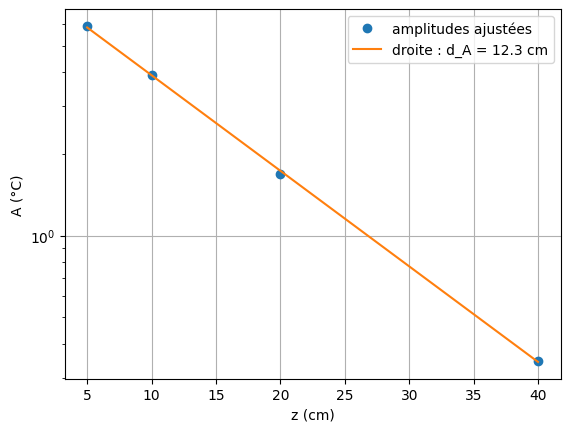

In [12]:
A_z = ajust["A"].to_numpy()
phi_z = ajust["phi"].to_numpy()

# ln A = ln A0 - z / d_A : droite de pente -1/d_A
pente_A, ordonnee_A = np.polyfit(zs, np.log(A_z), 1)
d_A = -1 / pente_A
DT_A = omega * d_A**2 / 2
A0_estime = np.exp(ordonnee_A)
print(f"d (amplitude) = {d_A:.2f} cm -> D_T = {DT_A:.0f} cm²/j ; amplitude en surface extrapolée A0 = {A0_estime:.2f} °C")

plt.figure()
plt.semilogy(zs, A_z, "o", label="amplitudes ajustées")
plt.semilogy(zs, np.exp(ordonnee_A + pente_A * zs), "-", label=f"droite : d_A = {d_A:.1f} cm")
plt.xlabel("z (cm)")
plt.ylabel("A (°C)")
plt.legend()
plt.grid(True)
plt.show()

**2b. Profondeur d'amortissement par la phase**

d (phase) = 12.13 cm -> D_T = 462 cm²/j
loam de l'exercice 1 : d = 11.94 cm, D_T = 448 cm²/j


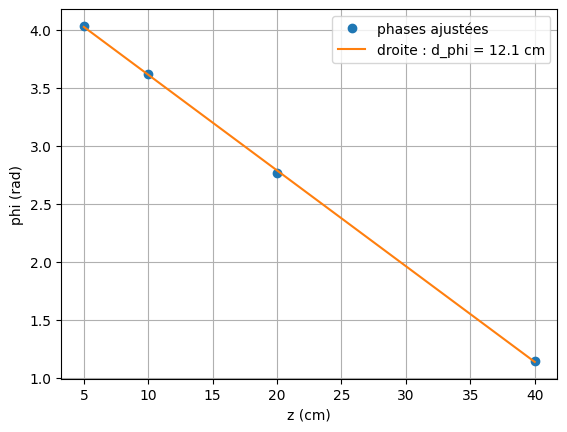

In [13]:
# phi = phi0 - z / d_phi : droite de pente -1/d_phi
pente_phi, ordonnee_phi = np.polyfit(zs, phi_z, 1)
d_phi = -1 / pente_phi
DT_phi = omega * d_phi**2 / 2
print(f"d (phase) = {d_phi:.2f} cm -> D_T = {DT_phi:.0f} cm²/j")
print(f"loam de l'exercice 1 : d = {d_loam:.2f} cm, D_T = {DT_loam:.0f} cm²/j")

plt.figure()
plt.plot(zs, phi_z, "o", label="phases ajustées")
plt.plot(zs, ordonnee_phi + pente_phi * zs, "-", label=f"droite : d_phi = {d_phi:.1f} cm")
plt.xlabel("z (cm)")
plt.ylabel("phi (rad)")
plt.legend()
plt.grid(True)
plt.show()

**3. Heure du maximum et retard avec la profondeur**

In [14]:
# le maximum de sin(omega t + phi) est atteint quand omega t + phi = pi/2, soit t_max = (pi/2 - phi) / omega, ramené dans [0, 1 j[
t_max = ((np.pi / 2 - phi_z) / omega) % 1.0
heure_max = 24 * t_max
retard = 24 * ((t_max - t_max[0]) % 1.0)             # retard (h) par rapport au capteur à 5 cm
retard_theorique = (zs - 5) / d_loam / omega * 24    # onde analytique : déphasage z/d, loam de l'exercice 1
for i in range(4):
    print(f"z = {zs[i]:2d} cm : maximum à {heure_max[i]:5.2f} h, retard sur 5 cm = {retard[i]:5.2f} h (théorie : {retard_theorique[i]:5.2f} h)")

z =  5 cm : maximum à 14.60 h, retard sur 5 cm =  0.00 h (théorie :  0.00 h)
z = 10 cm : maximum à 16.19 h, retard sur 5 cm =  1.58 h (théorie :  1.60 h)
z = 20 cm : maximum à 19.44 h, retard sur 5 cm =  4.84 h (théorie :  4.80 h)
z = 40 cm : maximum à  1.62 h, retard sur 5 cm = 11.02 h (théorie : 11.19 h)


**4. Même ajustement sans la dérive**

In [15]:
# modèle sans dérive : moyenne + onde journalière
def modele_sinus(t, Tm, A, phi):
    return Tm + A * np.sin(omega * t + phi)

lignes = []
for z in zs:
    T = tp[f"T_{z}cm"].to_numpy()
    popt, pcov = curve_fit(modele_sinus, t, T, p0=[20, 5, 0])
    Tm = popt[0]
    A = popt[1]
    phi = popt[2]
    if A < 0:
        A = -A
        phi = phi + np.pi
    erreur = modele_sinus(t, Tm, A, phi) - T
    rmse = np.sqrt(np.mean(erreur**2))
    lignes.append([z, Tm, A, phi, rmse])

ajust0 = pd.DataFrame(lignes, columns=["z_cm", "Tm", "A", "phi", "rmse"])
ajust0["phi"] = np.unwrap(ajust0["phi"])
print(ajust0.round(3))

pente_A0, ordonnee_A0 = np.polyfit(zs, np.log(ajust0["A"].to_numpy()), 1)
pente_phi0, ordonnee_phi0 = np.polyfit(zs, ajust0["phi"].to_numpy(), 1)
print(f"sans dérive : d_A = {-1 / pente_A0:.2f} cm, d_phi = {-1 / pente_phi0:.2f} cm")
print(f"RMSE moyen : {ajust0['rmse'].mean():.3f} °C sans dérive contre {ajust['rmse'].mean():.3f} °C avec dérive")

   z_cm      Tm      A    phi   rmse
0     5  18.866  5.986  4.016  0.541
1    10  18.881  4.007  3.604  0.523
2    20  18.908  1.791  2.787  0.535
3    40  18.867  0.317  1.483  0.543
sans dérive : d_A = 11.90 cm, d_phi = 13.89 cm
RMSE moyen : 0.536 °C sans dérive contre 0.146 °C avec dérive


**Commentaire (instructeur).** Les deux estimations concordent ($d$ = 12,1–12,4 cm, $D_T$ = 460–480 cm²/j, soit 3 à 7 % au-dessus des 448 cm²/j du loam) ; la méthode de l'amplitude
est en général la plus robuste, celle de la phase est sensible aux erreurs d'horloge et au bruit sur les faibles amplitudes (40 cm : $A \approx 0{,}3$ °C,
du même ordre que le bruit). Ignorer la dérive biaise surtout $\varphi$ ; sur le terrain, on ajoute aussi l'harmonique semi-diurne.
Cette « méthode de l'amplitude et de la phase » est la façon la plus simple de mesurer $D_T$ in situ (Horton et al. 1983).

## Exercice 3 — Schéma implicite pour l'équation de la chaleur  *(≈ 18 min)*

Résoudre $\partial T/\partial t = D_T\,\partial^2 T/\partial z^2$ sur une colonne de 100 cm avec $T(0,t) = T_m + A_0\sin(\omega t)$ en surface
et $T = T_m$ au fond (l'onde y est éteinte), par le schéma implicite :
$T_i^{n+1} - T_i^n = r\,(T_{i-1}^{n+1} - 2T_i^{n+1} + T_{i+1}^{n+1})$, $r = D_T\Delta t/\Delta z^2$ (système tridiagonal à chaque pas de temps).

1. Écrire `chaleur_implicite(z, T_init, dt, t_fin)` : coefficients $a, b, c$ de la matrice tridiagonale, `solve_banded`, boucle en temps ;
   la fonction renvoie la température à tous les nœuds et à tous les pas de temps. Vérifier un profil contre la solution analytique.
2. Vérification : partir de la solution analytique à $t = 0$ ; erreur RMS sur 0–50 cm à $t = 2{,}25$ j en fonction de $\Delta t$
   ($\Delta z$ = 0,25 cm), puis en fonction de $\Delta z$ ($\Delta t$ = 0,005 j, par rapport à une solution de référence à $\Delta z$ = 0,125 cm
   calculée avec le même $\Delta t$). Retrouver l'ordre 1 en temps et l'ordre 2 en espace.
3. Bilan d'énergie : vérifier que la variation d'énergie stockée $C\int (T - T_{init})\,dz$ égale l'intégrale du flux entrant en surface
   $-\lambda\,\partial T/\partial z|_0$ moins celle du flux sortant au fond (différences décentrées d'ordre 2) sur une simulation de 2 j
   ($C$ et $\lambda$ du loam, exercice 1).
4. Explicite : montrer que la solution diverge pour $r > 1/2$ ($\Delta z$ = 2 cm, $\Delta t = 1{,}03\,\Delta z^2/2D_T$) et reste bornée pour $r = 0{,}45$.

**Paramètres et solution analytique**

In [16]:
D_T = DT_loam     # cm²/j, loam à theta = 0,243 (exercice 1)
T_moy = 20.0      # température moyenne en surface (°C)
A0 = 10.0         # amplitude de l'onde en surface (°C)
L = 100.0         # longueur de la colonne (cm)

# onde journalière amortie : solution analytique pour une surface T = T_moy + A0 sin(omega t)
def analytique(z, t):
    d = np.sqrt(2 * D_T / omega)
    return T_moy + A0 * np.exp(-z / d) * np.sin(omega * t - z / d)

print("T(10 cm, t = 0,5 j) =", round(analytique(10.0, 0.5), 3), "°C")

T(10 cm, t = 0,5 j) = 23.216 °C


**1a. Le solveur implicite**

In [17]:
# schéma implicite : -r T_(i-1) + (1 + 2r) T_i - r T_(i+1) = T_i^n pour les noeuds intérieurs ;
# surface : T = T_moy + A0 sin(omega t) ; fond : T = T_moy ; T_init : profil initial (même taille que z)
def chaleur_implicite(z, T_init, dt, t_fin):
    nz = len(z)
    dz = z[1] - z[0]
    r = D_T * dt / dz**2
    n_pas = int(round(t_fin / dt))
    # coefficients de la matrice tridiagonale : a (sous-diagonale), b (diagonale), c (sur-diagonale)
    a = np.full(nz, -r)
    b = np.full(nz, 1 + 2 * r)
    c = np.full(nz, -r)
    # noeuds de surface et de fond : température imposée, la ligne se réduit à 1 * T = valeur
    b[0] = 1.0
    c[0] = 0.0
    a[-1] = 0.0
    b[-1] = 1.0
    # format « bande » de solve_banded : ligne 0 = c décalée, ligne 1 = b, ligne 2 = a décalée
    ab = np.zeros((3, nz))
    ab[0, 1:] = c[:-1]
    ab[1, :] = b
    ab[2, :-1] = a[1:]
    # boucle en temps : on garde tous les profils dans T_tous (une ligne par pas de temps)
    T = T_init.copy()
    T_tous = np.zeros((n_pas + 1, nz))
    T_tous[0] = T
    for k in range(1, n_pas + 1):
        t = k * dt
        membre_droit = T.copy()
        membre_droit[0] = T_moy + A0 * np.sin(omega * t)
        membre_droit[-1] = T_moy
        T = solve_banded((1, 1), ab, membre_droit)
        T_tous[k] = T
    return T_tous

print("solveur défini")

solveur défini


**1b. Première simulation et comparaison à la solution analytique**

dz = 0,5 cm, dt = 0,01 j : erreur RMS sur 0-50 cm à t = 2,25 j = 0.0322 °C


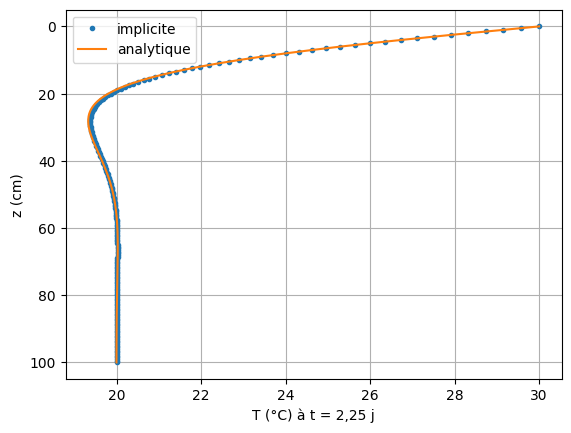

In [18]:
dz = 0.5
z = np.linspace(0, L, int(L / dz) + 1)
T_init = analytique(z, 0.0)                  # on part de l'onde établie
T_tous = chaleur_implicite(z, T_init, 0.01, 2.25)
T_num = T_tous[-1]                           # profil au dernier pas de temps (t = 2,25 j)
T_exact = analytique(z, 2.25)
haut = z <= 50
erreur_rms = np.sqrt(np.mean((T_num[haut] - T_exact[haut])**2))
print(f"dz = 0,5 cm, dt = 0,01 j : erreur RMS sur 0-50 cm à t = 2,25 j = {erreur_rms:.4f} °C")

plt.figure()
plt.plot(T_num, z, "o", markersize=3, label="implicite")
plt.plot(T_exact, z, "-", label="analytique")
plt.gca().invert_yaxis()
plt.xlabel("T (°C) à t = 2,25 j")
plt.ylabel("z (cm)")
plt.legend()
plt.grid(True)
plt.show()

**2a. Erreur en fonction du pas de temps (Δz = 0,25 cm)**

erreurs RMS (°C) : [0.578  0.3374 0.1502 0.078  0.0398 0.0162]
ordre observé en temps : 0.92


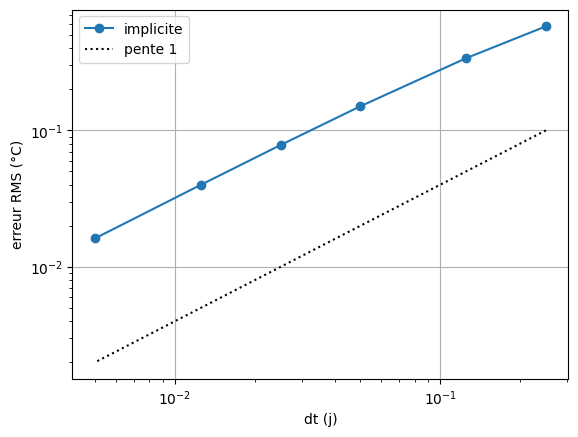

In [19]:
dz = 0.25
z = np.linspace(0, L, int(L / dz) + 1)
T_init = analytique(z, 0.0)
T_exact = analytique(z, 2.25)
haut = z <= 50

dts = np.array([0.25, 0.125, 0.05, 0.025, 0.0125, 0.005])
erreurs_dt = []
for dt in dts:
    T_tous = chaleur_implicite(z, T_init, dt, 2.25)
    T_num = T_tous[-1]
    erreurs_dt.append(np.sqrt(np.mean((T_num[haut] - T_exact[haut])**2)))
erreurs_dt = np.array(erreurs_dt)

# ordre observé = pente de ln(erreur) en fonction de ln(dt)
ordre_t, constante_t = np.polyfit(np.log(dts), np.log(erreurs_dt), 1)
print("erreurs RMS (°C) :", np.round(erreurs_dt, 4))
print(f"ordre observé en temps : {ordre_t:.2f}")

plt.figure()
plt.loglog(dts, erreurs_dt, "o-", label="implicite")
plt.loglog(dts, 0.4 * dts, "k:", label="pente 1")
plt.xlabel("dt (j)")
plt.ylabel("erreur RMS (°C)")
plt.legend()
plt.grid(True)
plt.show()

**2b. Erreur en fonction du pas d'espace (Δt = 0,005 j)**

erreurs RMS (°C) : [0.01868 0.00467 0.00117 0.00028]
ordre observé en espace : 2.02


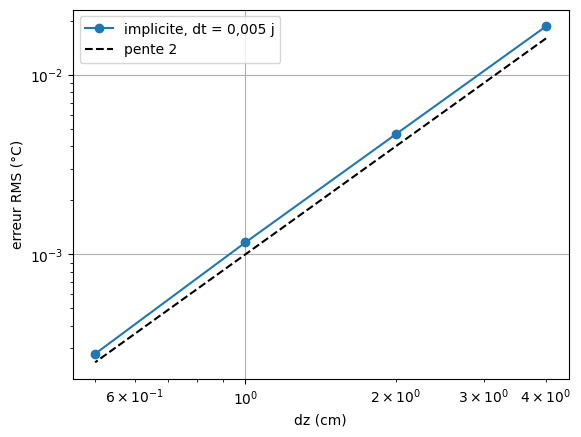

In [20]:
# à dt fixé, l'erreur en temps (0,016 °C à dt = 0,005 j, voir 2a) masquerait l'erreur en espace :
# on compare donc à une solution de référence à dz très fin (0,125 cm) calculée avec le même dt
dt = 0.005
z_ref = np.linspace(0, L, int(L / 0.125) + 1)
T_tous = chaleur_implicite(z_ref, analytique(z_ref, 0.0), dt, 2.25)
T_ref = T_tous[-1]

dzs = np.array([4.0, 2.0, 1.0, 0.5])
erreurs_dz = []
for dz in dzs:
    z = np.linspace(0, L, int(L / dz) + 1)
    T_tous = chaleur_implicite(z, analytique(z, 0.0), dt, 2.25)
    T_num = T_tous[-1]
    T_ref_z = np.interp(z, z_ref, T_ref)       # référence aux noeuds du maillage grossier
    haut = z <= 50
    erreurs_dz.append(np.sqrt(np.mean((T_num[haut] - T_ref_z[haut])**2)))
erreurs_dz = np.array(erreurs_dz)

ordre_z, constante_z = np.polyfit(np.log(dzs), np.log(erreurs_dz), 1)
print("erreurs RMS (°C) :", np.round(erreurs_dz, 5))
print(f"ordre observé en espace : {ordre_z:.2f}")

plt.figure()
plt.loglog(dzs, erreurs_dz, "o-", label="implicite, dt = 0,005 j")
plt.loglog(dzs, 0.001 * dzs**2, "k--", label="pente 2")
plt.xlabel("dz (cm)")
plt.ylabel("erreur RMS (°C)")
plt.legend()
plt.grid(True)
plt.show()

**3. Bilan d'énergie sur 2 jours**

In [21]:
dz = 0.5
dt = 0.001
z = np.linspace(0, L, int(L / dz) + 1)
T_init = np.full(len(z), T_moy)              # colonne uniforme à 20 °C au départ
T_tous = chaleur_implicite(z, T_init, dt, 2.0)
t_serie = np.arange(len(T_tous)) * dt        # instants des pas de temps (j)

# flux de chaleur G = -lambda dT/dz (W/m², > 0 vers le bas) par différence décentrée d'ordre 2, dz en m
G_haut = -lam_loam * (-3 * T_tous[:, 0] + 4 * T_tous[:, 1] - T_tous[:, 2]) / (2 * dz * 1e-2)
G_bas = -lam_loam * (3 * T_tous[:, -1] - 4 * T_tous[:, -2] + T_tous[:, -3]) / (2 * dz * 1e-2)

# énergie entrée par la surface et sortie par le fond (J/m²) : intégrale du flux en temps (secondes)
E_haut = np.trapezoid(G_haut, t_serie * sec_par_jour)
E_bas = np.trapezoid(G_bas, t_serie * sec_par_jour)
# énergie stockée dans la colonne (J/m²) : C * intégrale de (T - T_init) sur z (mètres)
E_stock = C_loam * np.trapezoid(T_tous[-1] - T_moy, z * 1e-2)
ecart = abs(E_stock - (E_haut - E_bas)) / abs(E_haut - E_bas)
print(f"énergie entrée en surface = {E_haut / 1e6:.4f} MJ/m² ; sortie au fond = {E_bas / 1e6:.4f} MJ/m²")
print(f"énergie stockée = {E_stock / 1e6:.4f} MJ/m² ; bilan (haut - bas) = {(E_haut - E_bas) / 1e6:.4f} MJ/m² ; écart relatif = {ecart:.2%}")

énergie entrée en surface = -0.9814 MJ/m² ; sortie au fond = 0.0347 MJ/m²
énergie stockée = -1.0101 MJ/m² ; bilan (haut - bas) = -1.0160 MJ/m² ; écart relatif = 0.59%


**4. Schéma explicite et condition de stabilité**

In [22]:
dz_e = 2.0
z_e = np.linspace(0, L, int(L / dz_e) + 1)
i10 = int(round(10 / dz_e))              # indice du noeud à 10 cm
dt_lim = dz_e**2 / (2 * D_T)             # pas de temps limite : r = 1/2
print(f"dt limite (r = 1/2) pour dz = 2 cm : {dt_lim:.5f} j = {dt_lim * 24 * 60:.1f} min")

for facteur in [0.9, 1.03]:
    dt_e = facteur * dt_lim
    r = D_T * dt_e / dz_e**2
    n_pas = int(round(2.0 / dt_e))
    T = np.full(len(z_e), T_moy)
    T10_max = 0.0
    for k in range(1, n_pas + 1):
        # explicite : la nouvelle température se calcule directement à partir de l'ancienne
        T_nouveau = T.copy()
        T_nouveau[1:-1] = T[1:-1] + r * (T[:-2] - 2 * T[1:-1] + T[2:])
        T_nouveau[0] = T_moy + A0 * np.sin(omega * k * dt_e)
        T_nouveau[-1] = T_moy
        T = T_nouveau
        if abs(T[i10]) > T10_max:
            T10_max = abs(T[i10])
    if T10_max > 100:
        verdict = "DIVERGE"
    else:
        verdict = "stable"
    print(f"explicite, dt = {facteur:.2f} dt_lim = {dt_e:.5f} j (r = {r:.3f}) : |T(10 cm)| max = {T10_max:.3g} °C -> {verdict}")

dt limite (r = 1/2) pour dz = 2 cm : 0.00446 j = 6.4 min
explicite, dt = 0.90 dt_lim = 0.00402 j (r = 0.450) : |T(10 cm)| max = 24.9 °C -> stable
explicite, dt = 1.03 dt_lim = 0.00460 j (r = 0.515) : |T(10 cm)| max = 1.59e+06 °C -> DIVERGE


**Commentaire (instructeur).** Les pentes observées (≈ 1 en $\Delta t$, ≈ 2 en $\Delta z$) confirment l'analyse du schéma implicite ; Crank–Nicolson ($\vartheta = 0{,}5$) serait
d'ordre 2 en temps et 10 à 100 fois plus précis à $\Delta t$ égal. Le bilan d'énergie ferme à 0,6 % (l'écart vient de l'évaluation du gradient en
surface au premier pas, où le saut de température est brutal, et de l'intégration trapèze ; il décroît avec $\Delta t$) ; la chaleur qui ressort par le fond
(≈ 3 %) rappelle qu'un bilan compte toutes les frontières : c'est le test de conservation à faire pour tout solveur. L'explicite explose dès que $r$ dépasse
1/2 de 3 % : avec $\Delta z$ = 2 cm, son pas limite (6 minutes) est 4 fois plus court que celui qu'exige la précision de l'onde journalière.

## Exercice 4 — HYDRUS-1D : conduction seule et conduction + convection  *(≈ 15 min)*

Projets `J09_chaleur_sans_convection` (loam, $h = -100$ cm, flux d'eau nul) et `J09_chaleur_avec_convection` (infiltration permanente
5 cm/j, $\theta = 0{,}405$) : surface à $20 \pm 10$ °C (période 1 j, maximum à 13 h), nœuds d'observation 5, 10, 20, 40 cm, 5 jours.

1. Lire `OBS_NODE.OUT` des deux projets (`read_obs_node`, variable `Temp`, nœuds 6, 11, 21, 41) et tracer $T(t)$ aux quatre profondeurs.
2. Sur le dernier jour ($t \ge 4$), ajuster $T = T_m + A\sin(\omega t + \varphi)$ à chaque profondeur ; régresser $\ln A$ et $\varphi$ sur $z$ :
   $d$ (amortissement) et longueur de phase, pour les deux projets.
3. Sans convection : comparer $d$ à $\sqrt{2D_T/\omega}$ avec $D_T$ du loam à $\theta = 0{,}243$ (exercice 1) et l'amplitude à chaque
   profondeur à $A_0 e^{-z/d}$.
4. Avec convection : calculer le nombre d'onde complexe $k = [-C_w q + \sqrt{(C_w q)^2 + 4 i\omega C\lambda}]/(2\lambda)$ (unités cm, j, g :
   $\lambda = \lambda_0(0{,}405) + \beta_T C_w q$, $\beta_T = 5$ cm, $q = 5$ cm/j) ; comparer $1/\mathrm{Re}(k)$ et $1/\mathrm{Im}(k)$ aux valeurs
   ajustées. Quelle part de la pénétration accrue vient de la convection, de la dispersion, du changement de $\theta$ ?

**Lecture des deux projets**

In [23]:
obs_sans = read_obs_node(HYD + "/J09_chaleur_sans_convection")
obs_avec = read_obs_node(HYD + "/J09_chaleur_avec_convection")
t_sans = obs_sans.index.to_numpy()
t_avec = obs_avec.index.to_numpy()
noeuds = [6, 11, 21, 41]            # numéros des noeuds d'observation
zs = np.array([5, 10, 20, 40])      # profondeurs correspondantes (cm)
print(obs_sans.head(3))

node       6                      11                   21                \
var         h   theta    Temp      h   theta  Temp      h   theta  Temp   
Time                                                                      
0.0010 -100.0  0.2426  19.999 -100.0  0.2426  20.0 -100.0  0.2426  20.0   
0.0020 -100.0  0.2426  19.992 -100.0  0.2426  20.0 -100.0  0.2426  20.0   
0.0033 -100.0  0.2426  19.955 -100.0  0.2426  20.0 -100.0  0.2426  20.0   

node       41                
var         h   theta  Temp  
Time                         
0.0010 -100.0  0.2426  20.0  
0.0020 -100.0  0.2426  20.0  
0.0033 -100.0  0.2426  20.0  


**1a. Températures aux nœuds d'observation — sans convection**

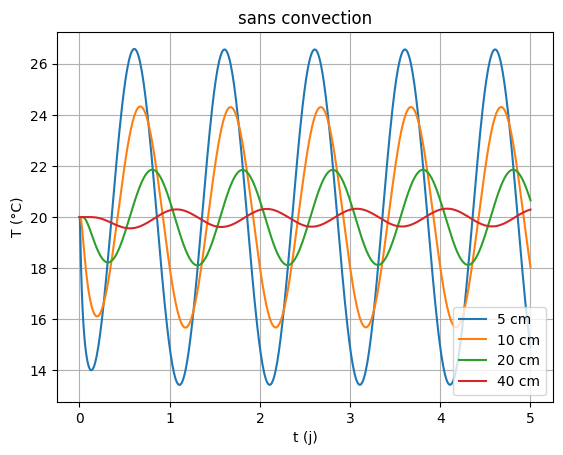

In [24]:
plt.figure()
for i in range(4):
    plt.plot(t_sans, obs_sans[(noeuds[i], "Temp")], label=f"{zs[i]} cm")
plt.xlabel("t (j)")
plt.ylabel("T (°C)")
plt.title("sans convection")
plt.legend()
plt.grid(True)
plt.show()

**1b. Températures aux nœuds d'observation — avec convection**

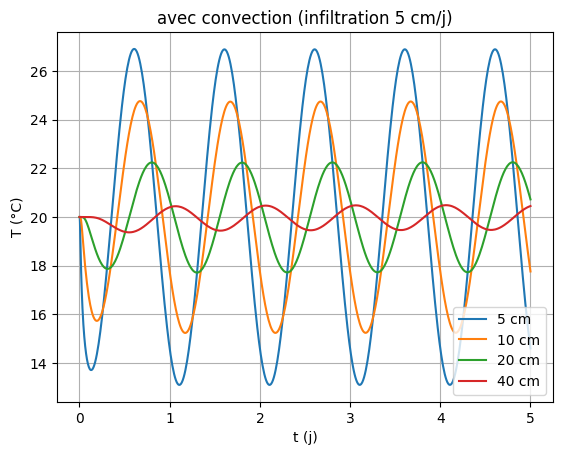

In [25]:
plt.figure()
for i in range(4):
    plt.plot(t_avec, obs_avec[(noeuds[i], "Temp")], label=f"{zs[i]} cm")
plt.xlabel("t (j)")
plt.ylabel("T (°C)")
plt.title("avec convection (infiltration 5 cm/j)")
plt.legend()
plt.grid(True)
plt.show()

**2a. Amplitude et phase sur le dernier jour — sans convection**

In [26]:
dernier_jour = t_sans >= 4.0
A_sans = []
phi_sans = []
for i in range(4):
    T = obs_sans[(noeuds[i], "Temp")].to_numpy()
    popt, pcov = curve_fit(modele_sinus, t_sans[dernier_jour], T[dernier_jour], p0=[20, 5, 0])
    A = popt[1]
    phi = popt[2]
    if A < 0:
        A = -A
        phi = phi + np.pi
    A_sans.append(A)
    phi_sans.append(phi)
A_sans = np.array(A_sans)
phi_sans = np.unwrap(np.array(phi_sans))

pente_A, ordonnee_A = np.polyfit(zs, np.log(A_sans), 1)
pente_phi, ordonnee_phi = np.polyfit(zs, phi_sans, 1)
d_amp_sans = -1 / pente_A
d_phase_sans = -1 / pente_phi
print("sans convection : A =", np.round(A_sans, 2), "°C")
print(f"d (amplitude) = {d_amp_sans:.2f} cm ; longueur de phase = {d_phase_sans:.2f} cm")

sans convection : A = [6.56 4.31 1.86 0.35] °C
d (amplitude) = 11.92 cm ; longueur de phase = 11.96 cm


**2b. Amplitude et phase sur le dernier jour — avec convection**

In [27]:
dernier_jour = t_avec >= 4.0
A_avec = []
phi_avec = []
for i in range(4):
    T = obs_avec[(noeuds[i], "Temp")].to_numpy()
    popt, pcov = curve_fit(modele_sinus, t_avec[dernier_jour], T[dernier_jour], p0=[20, 5, 0])
    A = popt[1]
    phi = popt[2]
    if A < 0:
        A = -A
        phi = phi + np.pi
    A_avec.append(A)
    phi_avec.append(phi)
A_avec = np.array(A_avec)
phi_avec = np.unwrap(np.array(phi_avec))

pente_A, ordonnee_A = np.polyfit(zs, np.log(A_avec), 1)
pente_phi, ordonnee_phi = np.polyfit(zs, phi_avec, 1)
d_amp_avec = -1 / pente_A
d_phase_avec = -1 / pente_phi
print("avec convection : A =", np.round(A_avec, 2), "°C")
print(f"d (amplitude) = {d_amp_avec:.2f} cm ; longueur de phase = {d_phase_avec:.2f} cm")

avec convection : A = [6.89 4.75 2.26 0.51] °C
d (amplitude) = 13.43 cm ; longueur de phase = 12.21 cm


**3. Sans convection : comparaison à l'onde analytique**

In [28]:
# onde analytique avec D_T du loam à theta = 0,243 (exercice 1) : d = d_loam
A_theorique = 10 * np.exp(-zs / d_loam)
retard_hydrus = (phi_sans[0] - phi_sans) / omega * 24      # retard (h) par rapport à 5 cm
retard_theorique = (zs - 5) / d_loam / omega * 24
print(f"analytique (theta = 0,243) : d = {d_loam:.2f} cm ; HYDRUS : d = {d_amp_sans:.2f} cm (amplitude), {d_phase_sans:.2f} cm (phase)")
print("amplitudes HYDRUS     :", np.round(A_sans, 2), "°C")
print("amplitudes A0 exp(-z/d) :", np.round(A_theorique, 2), "°C")
print("retard (h) HYDRUS     :", np.round(retard_hydrus, 2))
print("retard (h) théorie    :", np.round(retard_theorique, 2))

analytique (theta = 0,243) : d = 11.94 cm ; HYDRUS : d = 11.92 cm (amplitude), 11.96 cm (phase)
amplitudes HYDRUS     : [6.56 4.31 1.86 0.35] °C
amplitudes A0 exp(-z/d) : [6.58 4.33 1.87 0.35] °C
retard (h) HYDRUS     : [ 0.    1.6   4.79 11.18]
retard (h) théorie    : [ 0.    1.6   4.8  11.19]


**4. Avec convection : nombre d'onde complexe**

In [29]:
# quatre cas, en unités HYDRUS (g, cm, j) : lambda x f_lam, C x f_C, Cw x f_C (exercice 1), q en cm/j, beta_T en cm
cas = ["theta = 0,243, conduction seule", "theta = 0,405, conduction seule",
       "theta = 0,405, conduction + convection", "theta = 0,405, convection + dispersion 5 cm"]
theta_cas = [0.243, 0.405, 0.405, 0.405]
q_cas = [0.0, 0.0, 5.0, 5.0]
beta_cas = [0.0, 0.0, 0.0, 5.0]
for i in range(4):
    theta = theta_cas[i]
    q = q_cas[i]
    beta_T = beta_cas[i]
    # conductivité effective = conduction + dispersion thermique (beta_T Cw q)
    lam_h = lam_CH(theta, b1_loam, b2_loam, b3_loam) * f_lam + beta_T * Cw_h * q
    C_h = C_vol(theta, theta_s_loam, 0.0) * f_C
    v_T = Cw_h * q / C_h                     # vitesse de transport convectif de la chaleur (cm/j)
    k_onde = (-Cw_h * q + np.sqrt((Cw_h * q)**2 + 4j * omega * C_h * lam_h)) / (2 * lam_h)
    d_eff = 1 / k_onde.real                  # profondeur d'amortissement (cm)
    L_phase = 1 / k_onde.imag                # longueur de phase (cm)
    print(f"{cas[i]:45s} lambda = {lam_h / f_lam:.3f} W/m/K ; C = {C_h / f_C / 1e6:.3f} MJ/m³/K ; v_T = {v_T:.2f} cm/j ; d_eff = {d_eff:.2f} cm ; L_phase = {L_phase:.2f} cm")
print(f"HYDRUS sans convection : d_eff = {d_amp_sans:.2f} cm ; L_phase = {d_phase_sans:.2f} cm")
print(f"HYDRUS avec convection : d_eff = {d_amp_avec:.2f} cm ; L_phase = {d_phase_avec:.2f} cm")

theta = 0,243, conduction seule               lambda = 1.095 W/m/K ; C = 2.110 MJ/m³/K ; v_T = 0.00 cm/j ; d_eff = 11.94 cm ; L_phase = 11.94 cm
theta = 0,405, conduction seule               lambda = 1.378 W/m/K ; C = 2.787 MJ/m³/K ; v_T = 0.00 cm/j ; d_eff = 11.66 cm ; L_phase = 11.66 cm
theta = 0,405, conduction + convection        lambda = 1.378 W/m/K ; C = 2.787 MJ/m³/K ; v_T = 7.50 cm/j ; d_eff = 12.95 cm ; L_phase = 11.69 cm
theta = 0,405, convection + dispersion 5 cm   lambda = 1.499 W/m/K ; C = 2.787 MJ/m³/K ; v_T = 7.50 cm/j ; d_eff = 13.45 cm ; L_phase = 12.19 cm
HYDRUS sans convection : d_eff = 11.92 cm ; L_phase = 11.96 cm
HYDRUS avec convection : d_eff = 13.43 cm ; L_phase = 12.21 cm


**Commentaire (instructeur).** Sans convection, HYDRUS reproduit exactement l'onde analytique : $d = 11{,}9$ cm par l'amplitude comme par la phase, amplitudes 6,56 / 4,31 /
1,86 / 0,35 °C. Avec l'infiltration de 5 cm/j, $d_{eff}$ passe à 13,4 cm alors que la longueur de phase reste ≈ 12,2 cm : la convection
transporte l'onde vers le bas ($v_T = 7{,}5$ cm/j) sans modifier son déphasage. La solution à nombre d'onde complexe (13,45 et 12,2 cm)
reproduit HYDRUS ; la conduction seule à $\theta = 0{,}405$ donnerait 11,7 cm (la hausse de $C$ l'emporte sur celle de $\lambda$),
la convection apporte +1,3 cm et la dispersion thermique +0,5 cm.

## Pour aller plus loin

* Flux de chaleur en surface $G = -\lambda\,\partial T/\partial z|_0$ à partir des profils `NOD_INF.OUT` (toutes les 3 h) : amplitude ≈ 130 W/m²,
  avance de 3 h sur la température ; énergie stockée puis restituée chaque jour ≈ 3,6 MJ/m² (l'évaporation de 1,5 mm d'eau).
* Onde annuelle + onde journalière superposées : simuler 2 ans avec le schéma implicite et retrouver le retard saisonnier à 1 m.
* Coupler $\lambda(\theta(z,t))$ et $C(\theta(z,t))$ au profil d'humidité du J8 (redistribution) dans le solveur de l'exercice 3.
* Estimer $D_T$ par HYDRUS inverse (J10) à partir des séries de l'exercice 2.